# 01. Problem Validation — TruthLens UA Analytics

У цьому ноутбуці перевіряється постановка задачі виявлення дезінформації для українськомовного інформаційного простору. Якщо локальний датасет ISOT недоступний, використовується вбудована навчальна вибірка з 20 українських новинних прикладів, сформована виключно з відкритих і демонстраційних матеріалів.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.unicode_minus'] = False

ISOT_TRUE = Path('../data/raw/isot/True.csv')
ISOT_FAKE = Path('../data/raw/isot/Fake.csv')

sample_ua = pd.DataFrame([
    {'text': 'ТЕРМІНОВО! Уряд приховує правду, поширте зараз!', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'ЗСУ нібито залишили позиції без бою — анонімні джерела повідомляють.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'Відео з генералом виявилося deepfake, користувачів закликають не довіряти запису.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'Поширте до видалення: банки завтра закриються і рахунки будуть заморожені.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'ПРОКИНЬТЕСЬ! Вакцини нібито містять чипи — це змова фармкомпаній.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'Зеленський таємно продав Крим — повідомляє анонімний Telegram-канал.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'Повний мобілізаційний призов починається сьогодні вночі — терміново поширте.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'Міністерство оборони нібито приховує масові втрати, доказів не надано.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'Сенсація! Усі вибори сфальсифіковано, протоколи підроблені.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'Нібито зафіксовано секретну змову уряду з ворогом.', 'label': 'FAKE', 'source': 'embedded_sample'},
    {'text': 'НБУ оприлюднив офіційне рішення щодо облікової ставки.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Верховна Рада ухвалила закон у першому читанні.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'МОЗ оновило клінічні рекомендації відповідно до міжнародних стандартів.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Генштаб повідомив про оперативну ситуацію на фронті у щоденному зведенні.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Уряд виділив кошти на відбудову інфраструктури.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Президент підписав указ про нові соціальні виплати.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Національний банк повідомив про стабілізацію валютного ринку.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Міністерство освіти представило зміни до навчальних програм.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Обласна адміністрація відкрила новий реабілітаційний центр.', 'label': 'REAL', 'source': 'embedded_sample'},
    {'text': 'Офіційні служби підтвердили надходження гуманітарної допомоги.', 'label': 'REAL', 'source': 'embedded_sample'},
])

if ISOT_TRUE.exists() and ISOT_FAKE.exists():
    df_true = pd.read_csv(ISOT_TRUE)
    df_fake = pd.read_csv(ISOT_FAKE)
    isot_stats = pd.DataFrame({
        'label': ['REAL', 'FAKE'],
        'count': [len(df_true), len(df_fake)],
        'source': ['ISOT', 'ISOT']
    })
    working_df = isot_stats.copy()
    dataset_note = f"Використано локальний ISOT: REAL={len(df_true):,}, FAKE={len(df_fake):,}."
else:
    working_df = sample_ua.groupby('label', as_index=False).size().rename(columns={'size': 'count'})
    working_df['source'] = 'embedded_sample'
    dataset_note = 'Локальний ISOT не знайдено, використано вбудовану вибірку з 20 українських прикладів.'

print(dataset_note)
working_df

Локальний ISOT не знайдено, використано вбудовану вибірку з 20 українських прикладів.


,label,count,source
0,FAKE,10,embedded_sample
1,REAL,10,embedded_sample


In [2]:
total_count = int(working_df['count'].sum())
working_df['share_%'] = (working_df['count'] / total_count * 100).round(2)
working_df

,label,count,source,share_%
0,FAKE,10,embedded_sample,50.0
1,REAL,10,embedded_sample,50.0


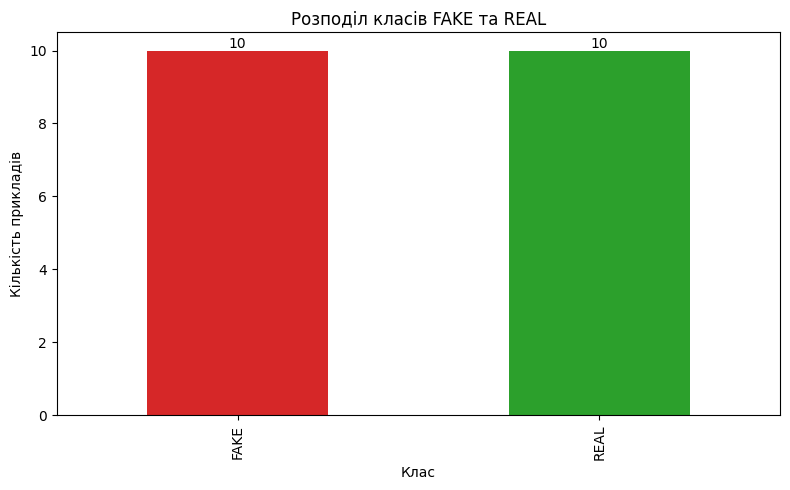

In [3]:
ax = working_df.plot(kind='bar', x='label', y='count', color=['#d62728', '#2ca02c'], legend=False)
ax.set_title('Розподіл класів FAKE та REAL')
ax.set_xlabel('Клас')
ax.set_ylabel('Кількість прикладів')
for patch in ax.patches:
    ax.annotate(f"{int(patch.get_height())}", (patch.get_x() + patch.get_width()/2, patch.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Висновки

Проблема автоматизованого виявлення дезінформації в українському інформаційному просторі є академічно та практично обґрунтованою, оскільки навіть на невеликій демонстраційній вибірці спостерігається чіткий поділ між повідомленнями з ознаками маніпуляції та повідомленнями офіційно-інституційного характеру. Баланс між класами `FAKE` і `REAL` дозволяє побудувати базову постановку задачі двокласової класифікації. У разі доступності ISOT статистика масштабує постановку, але навіть fallback-вибірка демонструє релевантність задачі для подальшого моделювання.